# 01 · Exploratory Data Analysis & Data-Quality Assessment

**Goal of this notebook:** understand the seven raw sources *before* building
anything, and catalogue every data-quality problem we will have to fix.

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from loan_default.config import load_config
from loan_default.data_loading import load_all

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

{'applications': (10734, 13),
 'customers': (8160, 6),
 'bureau': (14721, 8),
 'repayments': (249285, 8),
 'servicing': (10524, 7),
 'products': (4, 4),
 'branches': (6, 3)}

## 1. Loading the data

One row per: application (10,734), customer (8,160), bureau pull (14,721 — so
customers have several), repayment installment (249k), servicing record.

In [5]:
cfg = load_config()
raw = load_all(cfg)
{name: df.shape for name, df in raw.items()}

{'applications': (10734, 13),
 'customers': (8160, 6),
 'bureau': (14721, 8),
 'repayments': (249285, 8),
 'servicing': (10524, 7),
 'products': (4, 4),
 'branches': (6, 3)}

In [3]:
raw["applications"].head(3)

,application_id,customer_id,application_date,requested_amount,loan_term_months,declared_income,employment_type,employer_name,emirate,product_id,branch_id,channel,app_form_version
0,APP-500000,CUST-100000,31/05/2021,125100.0,36,7430.0,self employed,NaN,DXB,PRD-04,BR-DXB1,Branch,v1
1,APP-500001,CUST-100001,2021-04-15,36900.0,36,15064.0,Not Employed,NaN,DXB,PRD-02,BR-DXB2,Branch,v1
2,APP-500002,CUST-100002,15/01/2023,353500.0,24,21344.0,SALARIED,Employer_0575,Abu-Dhabi,PRD-01,BR-AUH2,Branch,v3


## 2. Data-quality issue #1 — mixed date formats

`application_date` mixes ISO (`2021-04-15`) and day-first (`31/05/2021`).
`bureau_pulls.pull_date` additionally contains **Excel serial numbers**
(`44547`). Same problem in `customers.date_of_birth`.

In [4]:
apps = raw["applications"]
sample = apps["application_date"].head(6).tolist()
print("application_date samples:", sample)

bur = raw["bureau"]
serial_like = bur["pull_date"].astype(str).str.fullmatch(r"\d{4,6}")
print(f"\nbureau pull_date that are Excel serials: {serial_like.sum():,} "
      f"of {len(bur):,} ({serial_like.mean():.1%})")
print("examples:", bur.loc[serial_like, "pull_date"].head(3).tolist())

application_date samples: ['31/05/2021', '2021-04-15', '15/01/2023', '2022-09-24', '44944', '2021-11-23']

bureau pull_date that are Excel serials: 1,442 of 14,721 (9.8%)
examples: ['44547', '44257', '45019']


## 3. Data-quality issue #2 — categorical variants

`employment_type` has **13 spellings** for 3 real categories.
`emirate` is written in mixed case / abbreviations **and** is contaminated with
acquisition-channel values (`Web`, `Online`) that are not emirates at all.

In [5]:
print("employment_type raw values:\n", apps["employment_type"].value_counts(), "\n")
print("emirate raw values:\n", apps["emirate"].value_counts())

employment_type raw values:
 employment_type
SALARIED         1373
salaried         1335
Salaried         1331
Salary           1322
FT-Salaried      1286
self employed     817
Self-Employed     779
SE                746
self-employed     712
Self Emp          685
unemployed        132
Unemployed        111
Not Employed      105
Name: count, dtype: int64 

emirate raw values:
 emirate
Dubai        1493
dubai        1486
DXB          1426
AUH           820
Abu-Dhabi     819
Abu Dhabi     783
AbuDhabi      746
Web           569
ONLINE        553
Sharjah       546
SHJ           521
Online        497
Shj           475
Name: count, dtype: int64


The `emirate` contamination is a leak of the acquisition channel into a
geography field — most likely an app-form/versioning artefact. We map the real
emirates to canonical names and keep a boolean flag for the contaminated rows.

In [6]:
contaminated = apps["emirate"].str.lower().isin(["web", "online"])
print(f"emirate holds a channel value in {contaminated.sum():,} rows "
      f"({contaminated.mean():.1%})")

emirate holds a channel value in 1,619 rows (15.1%)


## 4. Data-quality issue #3 — implausible declared income

Declared income (monthly AED) spans 2k to **50,000,000** against a median near
14k. The extreme tail is data-entry error (annual figures / trailing-zero
typos), not real income. We winsorise to a plausible band rather than drop
the applicant.

min        2218.0
50%       14158.5
max    50000000.0
Name: declared_income, dtype: float64


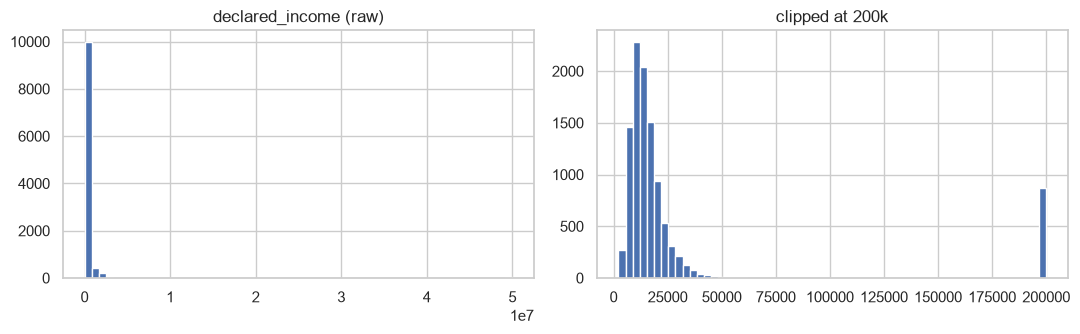

In [7]:
inc = apps["declared_income"]
print(inc.describe()[["min", "50%", "max"]])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(inc, bins=60); ax[0].set_title("declared_income (raw)")
ax[1].hist(inc.clip(upper=200_000), bins=60); ax[1].set_title("clipped at 200k")
plt.tight_layout(); plt.show()

## 5. Missingness and duplicates

In [8]:
print("Missing per column (applications):")
print((apps.isna().mean().round(3)[lambda s: s > 0]).to_string() or "none")
print("\nDuplicate application_id:", apps["application_id"].duplicated().sum())
print("Duplicate customer rows :", raw["customers"]["customer_id"].duplicated().sum())

Missing per column (applications):
employer_name    0.215

Duplicate application_id: 0
Duplicate customer rows : 0


## 6. Join integrity across systems

The join is *not* clean: some applications reference customers missing from the
master, and some have no servicing outcome (so they cannot be labelled).

In [9]:
srv, cust = raw["servicing"], raw["customers"]
print("apps -> customers missing :",
      (~apps["customer_id"].isin(cust["customer_id"])).sum())
print("apps -> servicing missing :",
      (~apps["application_id"].isin(srv["application_id"])).sum())
print("customers with >1 bureau pull:",
      int((bur["customer_id"].value_counts() > 1).sum()))

apps -> customers missing : 107
apps -> servicing missing : 210
customers with >1 bureau pull: 4443


The multiple bureau pulls per customer are the reason we must do a
**point-in-time join** later: at scoring time we may only use the pull that
existed *on or before* the application date. Using a later pull would leak the
future into the model.

## 7. The outcome fields (for target design, not features)

`loan_servicing` describes how each loan *performed*. These are outcomes — they
will define our target in notebook 02, but they can never be model inputs.

In [10]:
print(srv["final_loan_status"].value_counts(), "\n")
print("max_dpd_ever describe:\n", srv["max_dpd_ever"].describe()[["min", "50%", "max"]])

final_loan_status
Active         5211
Closed-Good    4435
Written-Off     739
Defaulted       139
Name: count, dtype: int64 

max_dpd_ever describe:
 min       0.0
50%      16.0
max    1166.0
Name: max_dpd_ever, dtype: float64


In [ ]:
df = pd.read_csv("data/repayments.csv")


## Observations

### Applications dataset
1. **declared_income** and **requested_amount** are highly correlated, as the declared_income increases, requested loan_amount.

2. **employer_name** has **2308 (21.5 %)** of missing data.

3. **application_date** has variable date format which needs to be fixed. eg : **31/05/2021, 2021-04-05, 444944**. (inconsistent label)

4. min **requested_amount** is **7500** and Max is **750K**, requested_amount is right skewed which suggest that very large requested loan are rare, large requeste loan should be check for outliers. This variable might required log_transformation before applying any linear model.

5. **loan_term_months** varies from **12 months to 60 months** which is basicaly from **1 year to 5 year**, where most people opt for **35% apply for 3 years terms, 28% for 2 years, 18% for 4 year**

6. **declared_income** is also right skewed. Where median income for the applicant is around **14k**, 95th percentile income around **1.2 Million**, but there some outliers of **50 Million** applicant.

7. **employment_type** column also needs to be normalized as the as salaried and self-employed have different variant, which needs to be standarized. eg : **salaried : Salary, salaried, FT-Salaried, self-employed : SE, self-employed**
(inconsistent-label)

8. **emirate** column also consist inconsistent label such as **"Dubai", "DXB", "dubai"** etc. This column also needs to be standarized. But still roughly **40%** values refer to Dubai, **28%** of the value from Abu-Dhabi, **10%** of the value from onilne

9. People majorly apply for **Product-1 (42%)** then followed by **Product-2(23%)**

10. **Branch** brings in the major applications around **50%** , remaining **30%** comes from **online** and remaining **20%** from **Direct selling agent**.

11. app_form_version are basically nearly equally distributed, we might need to see does the from application version have impact on loan approval case


### customer dataset
1. date_of_birth : 3 percent of the data for date_of_birth is missing, minimum dob (1959) to maximum dob (2021), 2021 seems wired as child can not apply for loan

2. gender : 67% of the applicants are Male

3. nationality_group : 51% of the applicant are expat from ASIA, remainging 20% from GCC and 10% from Others, hence 80 percent of loan application are from expats. We can check weather the loan percent approval is more for local or expat

4. marital_status : 
    Married --> 50%
    Single --> 42%
    Divorced --> 8%

5. dependents_count :
    suprisingly the dependent distribution is 20 percent across each count 4,3,2,1,0


### bureau dataset :
1. bureau_score : score is normally distributed from range of 300 to 900 but 900 weriedly vary large in count which 1625 of records which 11 percent of dataset

2.num_enquires_last_3m : most of the people make around max 2 enquires which covers 55 percent of the people, there is single person who has made max 11 enquiries

3. total_outstanding_debt : the histogram of it is right skewed which suggest most of the people have low outstanding debt

4. num_dpd_90_last_12m : mostly data is varied from 0 to 5 times each section about 15% and max is 8, generally people with higher dpd are more riskier to pay loan, as these people have not paid loan on times in past.

5. has_long_tenor_loan : 70% of people donot have longer tenure.

6. pull_date : pull_date format needs to be fixed as it varied dateformat.


### branches dataset :
1. branch_type : there are three types of branches - **Flagship, Standard, Digital**


### Loan Servicing dataset :
1. final_loan_status is highly correlated with managing unit, max_dpd_ever, num_late_payments_total

2. final_loan_status : 50 percent of the loan are active loans, 42% loan cloased-good, 7% written off and 1.3% defaulted

3. max_dpd_ever : median of max_dpd is around 16 days and max is 1166 which is rare

4. num_late_payments_total : varies from 0 to 40 where 5th percentile is 0 and 95th is 11

5. was_restructured : mostly loan donot go for restructuring

6. managing_unit : defaulted loans for might go for the collection recovery unit

7. recovery_amount : most the recovery amount is zero which means it very hard to recover money once the loan go defaulted, written off



### repayments dataset
1. dataset has duplicate rows 
2. paid date has missing values
3. paid_amount has missing values hence which suggest payment is still due, paid amount has negative amount which is weired need to figure out why these values are negative.
4. due_date has different date format which needs to be standarized
5. paid_date has different date format which needs to be standarized

### Takeaways carried into the next notebooks
1. Parse three date formats (ISO / day-first / Excel serial).
2. Collapse `employment_type` to 3 categories; canonicalise `emirate` + flag
   channel contamination.
3. Winsorise `declared_income`.
4. Point-in-time bureau join to avoid leakage.
5. `Active` loans have no matured outcome — decide how to treat them (nb 02).
6. Drop applications with no servicing outcome (unlabellable).